Import libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [9]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [ ]:
#First 5 Rows show
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
#Last 5 Rows show
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


Check dataset shape and structure

In [ ]:
print("Dataset Shape:", df.shape)
print("\nDataset Structure:")
df.info()

Dataset Shape: (4000, 28)

Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Ni

Data types examined

In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
 df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


**Missing values identified and handled**

*   Checked for missing values.
*   Missing values were found in Rainfall_mm, Soil_Moisture_pct, and Yield_Tonnes_Ha.
*   List itemMissing values were replaced with the mean of their respective columns.







In [10]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].mean())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].mean())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].mean())

**Duplicate records identified and handled**


*   Checked the dataset for duplicate records.

*   Duplicate records were removed if present.





In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

**Descriptive/statistical analysis**


*   Performed descriptive statistical analysis.

*   Examined count, mean, standard deviation, minimum and maximum values.



In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.185807,3.81818,11.960834,1.121186,0.641461,6.678828,31.216452,17.015074,27.742681,...,0.101747,13.307831,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,585.950000,26.90000,63.000000,7.300000,6.690000,26.500000,120.100000,57.500000,105.100000,...,0.830000,1.750000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.880000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


**Outliers investigated**


*   Investigated outliers in important numerical variables.
*   Used boxplots to identify unusually high or low values.



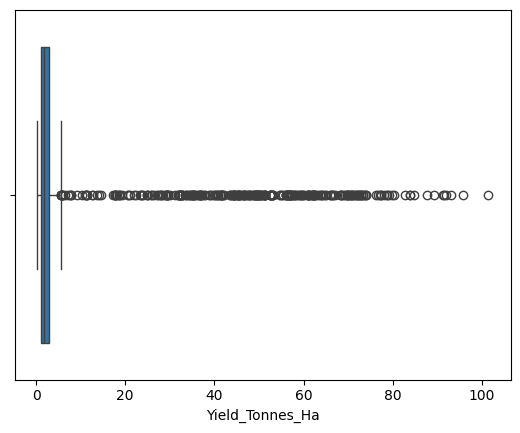

In [ ]:
sns.boxplot(x=df['Yield_Tonnes_Ha'])
plt.show()

**Univariate analysis**


*   Analyzed individual variables separately.
*  Studied the distribution of agricultural variables using graphs.



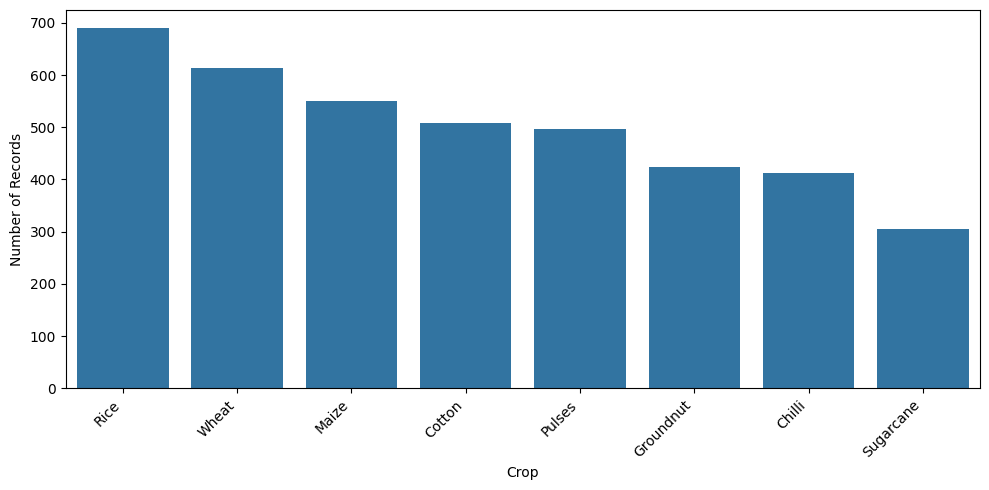

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Crop',order=df['Crop'].value_counts().index)
plt.xticks(rotation=45,ha='right')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

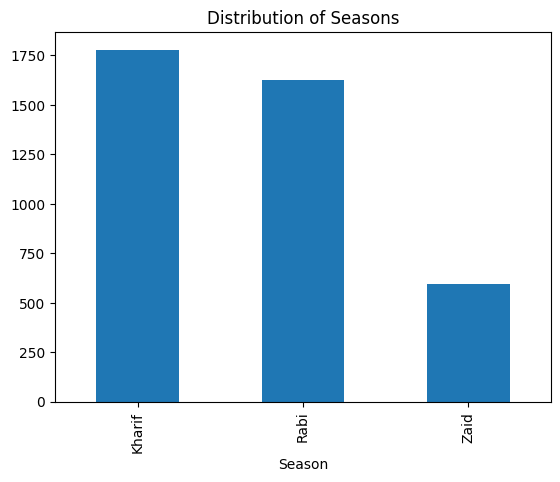

In [ ]:
df['Season'].value_counts().plot(kind='bar')
plt.title('Distribution of Seasons')
plt.show()

Seasons distribution (pie chart)

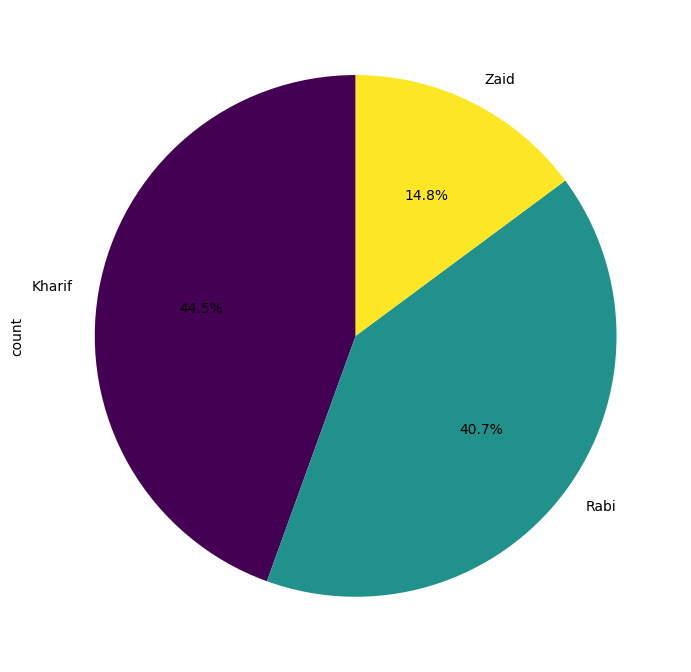

In [ ]:
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap='viridis')
plt.tight_layout()
plt.show()


**Bivariate analysis**


*   Analyzed the relationship between two variables.
*  Compared rainfall with agricultural yield.






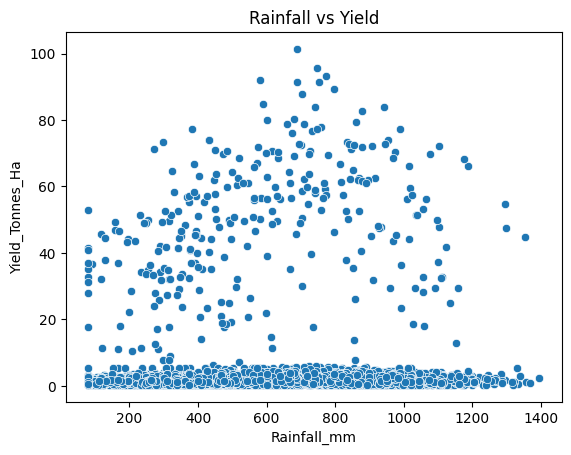

In [ ]:
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', data=df)
plt.title('Rainfall vs Yield')
plt.show()

**Multivariate analysis**


*   Analyzed multiple variables together.
*  Examined how different agricultural factors vary with yield.



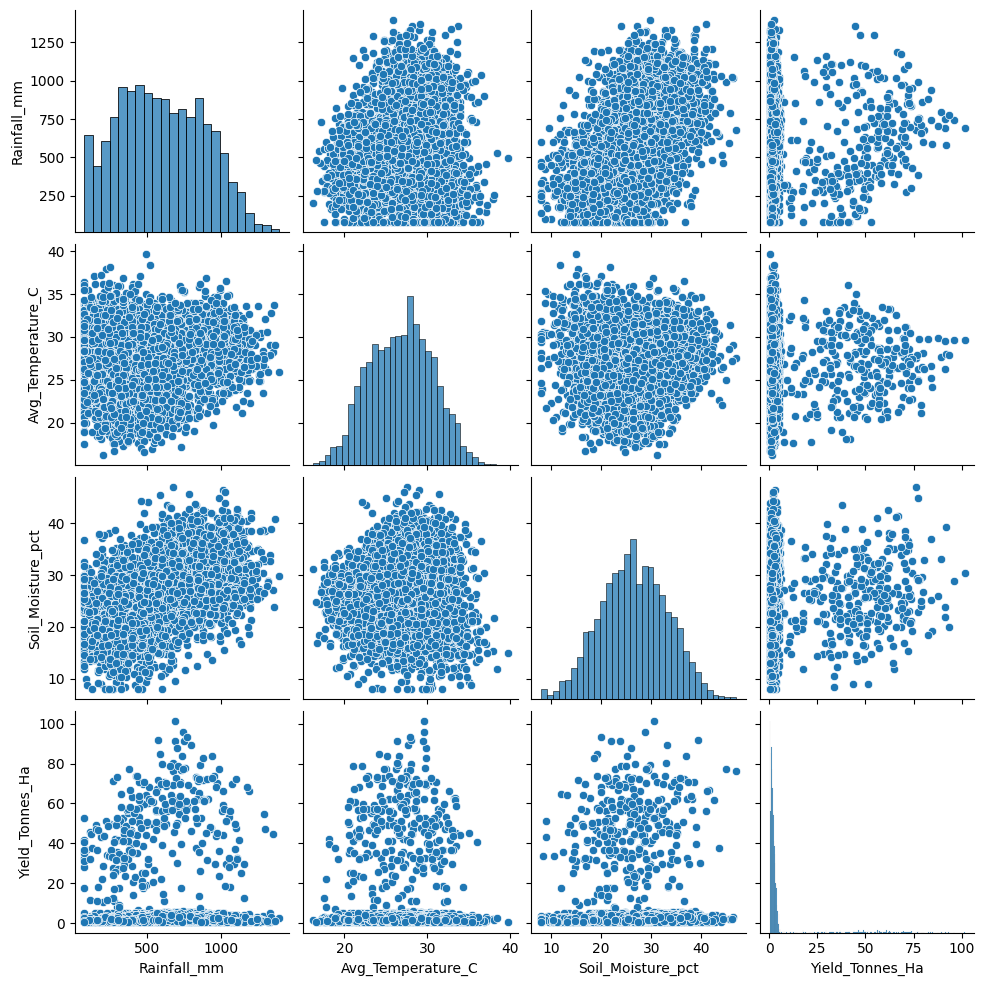

In [ ]:
sns.pairplot(df[['Rainfall_mm',
                 'Avg_Temperature_C',
                 'Soil_Moisture_pct',
                 'Yield_Tonnes_Ha']])
plt.show()

**Correlation analysis**


*    Examined correlations between numerical variables.
*   Identified variables that have stronger positive or negative relationships.



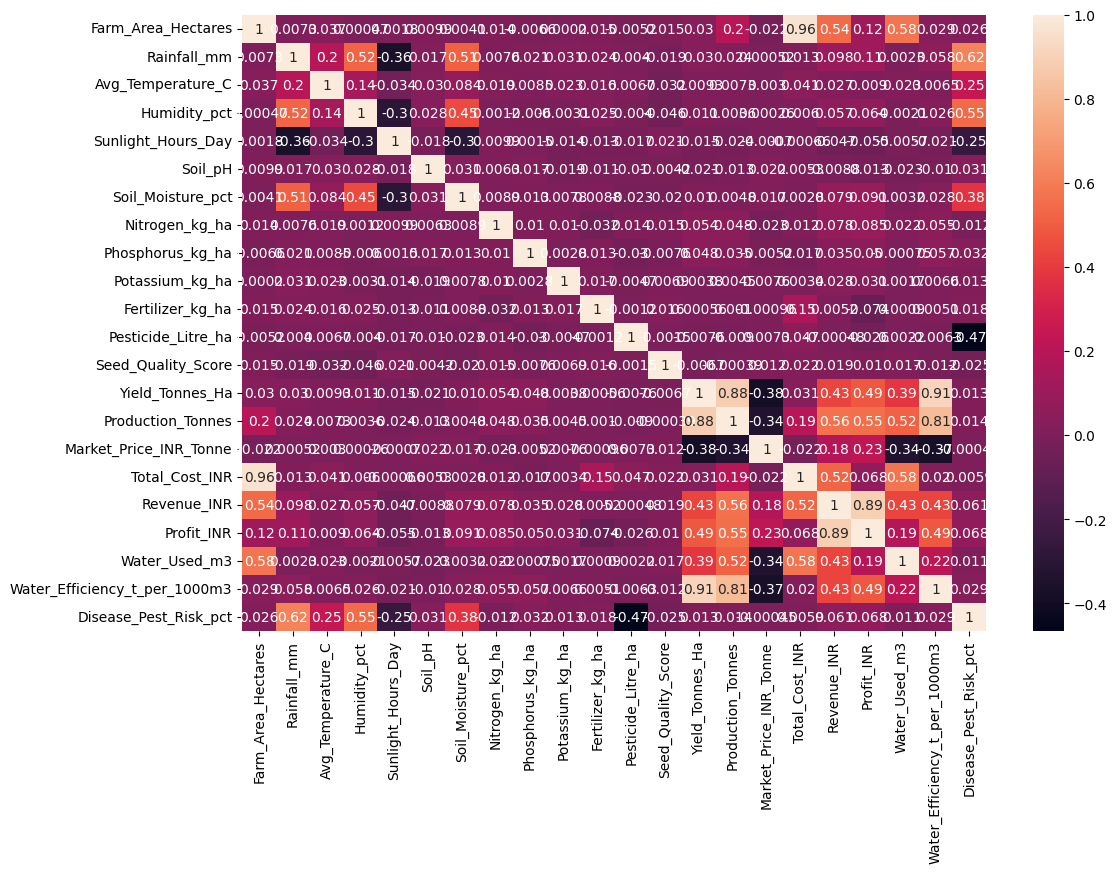

In [ ]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)
plt.show()

**Seasonal comparisons**


* Compared agricultural performance across different seasons.
*  Examined differences in yield, production and profit.



In [ ]:
df.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']].mean()

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Season,,,
Kharif,5.642504,46.311192,178914.647555
Rabi,5.082835,41.486712,87689.470191
Zaid,4.671032,38.886111,-24804.824916


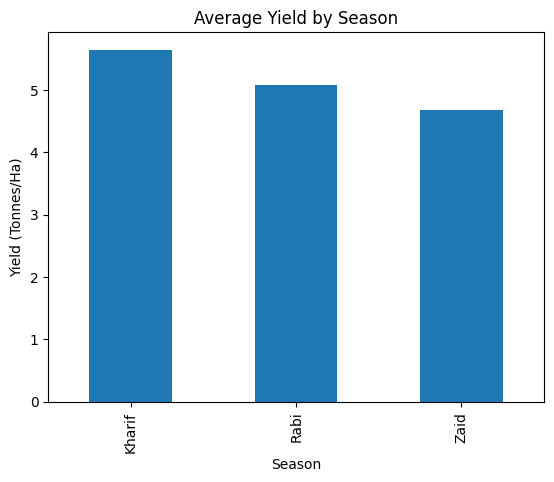

In [ ]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean().plot(kind='bar')
plt.title('Average Yield by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

**Designed analyses**


```
# These analyses focus on crop performance, irrigation efficiency, and seasonal profitability.
#The results help identify useful patterns for agricultural planning.
```



**Analysis 1: Best Performing Crop**


> **Question**: Which crop has the highest average yield?
















In [21]:
df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.665512
Maize,2.735667
Rice,2.472239
Wheat,2.119513
Chilli,1.585614
Groundnut,1.364535
Cotton,1.257583
Pulses,0.935748


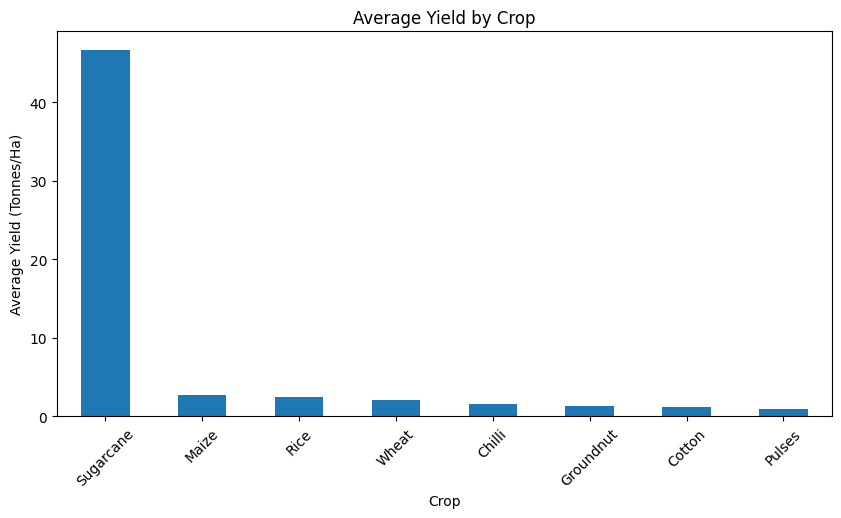

In [22]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
crop_yield.plot(kind='bar', figsize=(10,5))
plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

**Analysis 2: Irrigation Efficiency**


> **Question**:Which irrigation method has the highest water efficiency?



In [19]:
df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)


,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


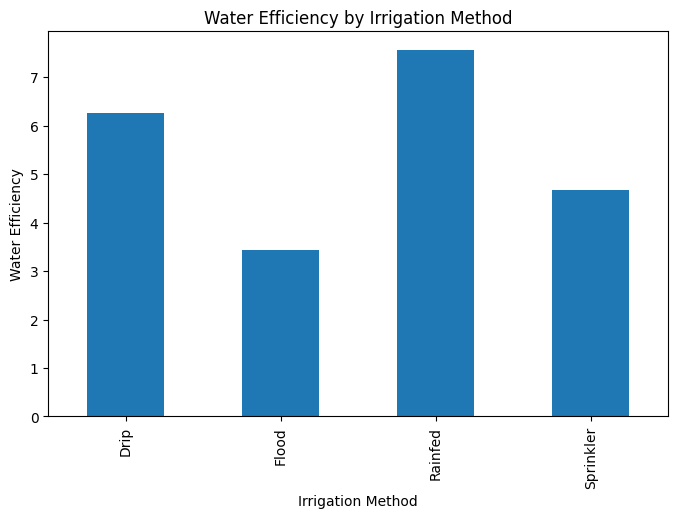

In [20]:
water_eff = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean()

water_eff.plot(kind='bar', figsize=(8,5))
plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency')
plt.show()

**Analysis 3: Seasonal Profitability**


>**Question** :Which season has the highest average profit?



In [13]:
df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)


,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


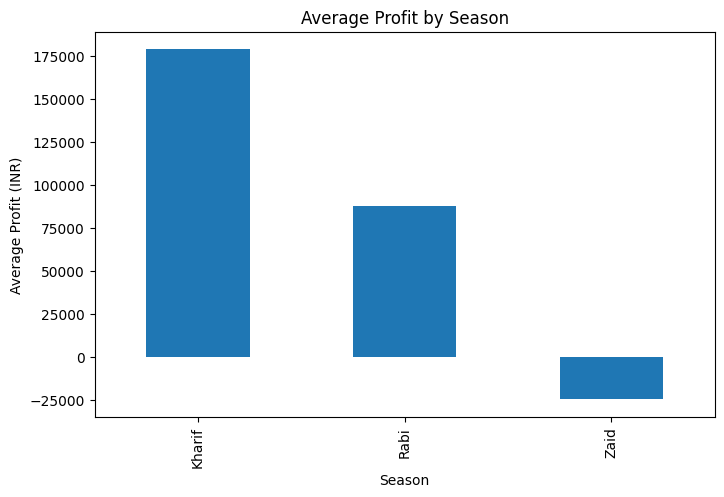

In [23]:
season_profit = df.groupby('Season')['Profit_INR'].mean()

season_profit.plot(kind='bar', figsize=(8,5))
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

**Meaningful Insights**




>project statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

1 — Best crop by yield

In [24]:
df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.665512
Maize,2.735667
Rice,2.472239
Wheat,2.119513
Chilli,1.585614
Groundnut,1.364535
Cotton,1.257583
Pulses,0.935748


2 — Best irrigation method

In [25]:
df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


3 — Best season by profit

In [26]:
df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


4 — Best season by yield

In [27]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Season,
Kharif,5.642504
Rabi,5.082835
Zaid,4.671032


5 — Rainfall and yield relationship

In [32]:
df[['Rainfall_mm', 'Yield_Tonnes_Ha']].corr()

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.030455
Yield_Tonnes_Ha,0.030455,1.000000


6 — Temperature and yield relationship

In [29]:
df[['Avg_Temperature_C', 'Yield_Tonnes_Ha']].corr()

,Avg_Temperature_C,Yield_Tonnes_Ha
Avg_Temperature_C,1.000000,0.009302
Yield_Tonnes_Ha,0.009302,1.000000


7 — Soil moisture and yield relationship

In [30]:
df[['Soil_Moisture_pct', 'Yield_Tonnes_Ha']].corr()

,Soil_Moisture_pct,Yield_Tonnes_Ha
Soil_Moisture_pct,1.000000,0.010096
Yield_Tonnes_Ha,0.010096,1.000000


8 — Highest average production by season

In [31]:
df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111



1.   Crop-wise yield: Sugarcane has the highest average yield at 46.67 tonnes/ha, while Pulses has the lowest at 0.94 tonnes/ha.

2.   Irrigation efficiency: Rainfed farming shows the highest average water efficiency at 7.56 t/1000 m³, followed by Drip irrigation at 6.27 t/1000 m³.

1. Seasonal profit: Kharif has the highest average profit of about ₹178,915, while Zaid shows an average loss of about ₹24,805.

1.   Seasonal yield: Kharif has the highest average yield at 5.64 tonnes/ha, followed by Rabi (5.08) and Zaid (4.67).

1.   Rainfall vs yield: The correlation is 0.03, indicating a very weak positive relationship between rainfall and yield in this dataset.
2.   Temperature vs yield: The correlation is 0.009, showing almost no linear relationship between average temperature and yield.


2.   Soil moisture vs yield: The correlation is 0.01, indicating almost no linear relationship between soil moisture and yield in this dataset.


2.   Seasonal production: Kharif has the highest average production at 46.31 tonnes, followed by Rabi (41.49) and Zaid (38.89).












**Evidence-Based Recommendations**



*   Focus on Kharif-season farming where suitable because it shows the highest average yield, production and profit.
*   Select high-performing crops based on local conditions and expected yield.


*   Promote efficient irrigation practices to improve water utilization.
* Investigate the causes of Zaid-season losses before increasing investment in this season.


* Consider multiple agricultural factors rather than relying only on rainfall, temperature or soil moisture when planning crop production.







**Limitations**




*   The analysis is based only on the available dataset.

*   Some environmental factors may have complex relationships that simple correlation cannot capture.
*  Results may vary across different regions, farms and years.


* The analysis does not establish cause-and-effect relationships.


*  Economic results can change with market prices and production costs.








**Final Conclusion**





> The Seasonal Agriculture Performance Analysis shows meaningful differences in crop performance, irrigation efficiency and economic outcomes across crops and seasons. Kharif shows the strongest overall performance, while Zaid has lower average yield and negative average profit. The analysis also shows very weak linear relationships between rainfall, temperature, soil moisture and yield. These findings can help farmers and agricultural planners make better decisions regarding crop selection, seasonal planning, resource utilization and profitability.






checkpoint list

---


1.Dataset loaded successfully ✅

2.Top 5 rows analyzed ✅

3.Dataset shape and structure examined ✅

4.Data types examined ✅

5.Missing values identified and handled ✅

6.Duplicate records identified and handled ✅

7.Descriptive/statistical analysis performed ✅

8.Outliers investigated ✅

9.Univariate analysis completed ✅

10.Bivariate analysis completed ✅

11.Multivariate analysis completed ✅

12.Correlation analysis completed ✅

13.Seasonal comparisons performed ✅

14.At least 3 student-designed analyses completed ✅

15.At least 8 meaningful insights documented ✅

16.Evidence-based recommendations provided ✅

17.Limitations discussed ✅

18.Final conclusion provided ✅